# Import Libraries

In [86]:
import numpy as np
import pandas as pd 
from tensorflow.keras.optimizers import Nadam


### Data loading

In [31]:
# For SKUs starting with '90'
# Data loading
df = pd.read_csv('../data/ForecastDataset_from_2016_to_2025_for_SKUs_started_with_90.csv')

In [32]:
df.shape

(533948, 9)

In [4]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState
0,AIRD,62181848,12/19/2022,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA
1,AIRD,60849149,7/8/2021,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA
2,AIRD,60849335,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR
3,AIRD,60849349,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT
4,AIRD,60849449,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD


In [5]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_Category', 'Channel', 'ShipToState'],
      dtype='object')

In [6]:
df.nunique()

ProductFamily             1
Order_ID             479881
OrderDate              3103
SKU_Description          20
WareHouseQuantity        13
SKU                      21
SKU_Category              3
Channel                  34
ShipToState              88
dtype: int64

In [7]:
df.isna().sum()

ProductFamily          0
Order_ID               0
OrderDate              0
SKU_Description      544
WareHouseQuantity      0
SKU                    0
SKU_Category         544
Channel               12
ShipToState           92
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(533300, 9)

### Feature Engineering

In [10]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

In [11]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState,Week,Month,Year
0,AIRD,62181848,2022-12-19,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA,2022-12-19,12,2022
1,AIRD,60849149,2021-07-08,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA,2021-07-05,7,2021
2,AIRD,60849335,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR,2021-07-05,7,2021
3,AIRD,60849349,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT,2021-07-05,7,2021
4,AIRD,60849449,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD,2021-07-05,7,2021


### Range Of SKU's

In [12]:
def print_date_ranges(df, sku_list=None):
    """
    Prints the overall dataset date range and individual date ranges for specified SKUs.

    Parameters:
    df (pd.DataFrame): DataFrame containing at least 'OrderDate' and 'SKU' columns.
    sku_list (list, optional): List of SKU strings to check date ranges for.
    """
    print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())
    
    if sku_list:
        for sku in sku_list:
            df_sku_check = df[df['SKU'] == sku]
            if not df_sku_check.empty:
                print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())
                # print(f"Total weekly data points for this SKU: {df_sku_check.shape[0]}")
            else:
                print(f"No data found for SKU: {sku}")
                


In [13]:
sku_list = ['90AD350AD01', '90AD200AD01', '90AD01AT01-W', '90AD02AD01', '90AD550AD01']
print_date_ranges(df, sku_list)


Full dataset date range: 2016-12-23 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD350AD01: 2022-09-15 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD200AD01: 2022-06-04 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD01AT01-W: 2019-08-16 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD02AD01: 2021-05-25 00:00:00 to 2023-06-30 00:00:00
Selected SKU date range 90AD550AD01: 2022-09-15 00:00:00 to 2025-07-28 00:00:00


### Data Splitting: Training and Testing (For Checking Accuracy)
- For Testing : April, May, June 2025
- For Training : Sep 22 to March 31

In [14]:
import pandas as pd
from dateutil.relativedelta import relativedelta


# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create 'Week' column as week start date (Monday)
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# Group weekly by SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter for the specific SKU
sku = '90AD350AD01'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()

# Add week start and end dates
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# -----------------------
# Split Test & Train
# -----------------------

# Test Data: April, May, June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-04-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-07-01'))
]

# Train Data: Before April 2025
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-04-01')
]


# -----------------------
# TRAIN DATA RANGE INFO
# -----------------------
# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")


print("\nTrain Data:")
print(train_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))

print("\nTest Data:")
print(test_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))




Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13

Train Data:
     Week_Start   Week_End  WareHouseQuantity
786  2022-09-12 2022-09-18                  1
801  2022-09-26 2022-10-02                  5
821  2022-10-17 2022-10-23                 17
831  2022-10-24 2022-10-30                 84
842  2022-10-31 2022-11-06                125
...         ...        ...                ...
1891 2025-02-24 2025-03-02                398
1902 2025-03-03 2025-03-09                447
1912 2025-03-10 2025-03-16                482
1922 2025-03-17 2025-03-23                596
1931 2025-03-24 2025-03-30                721

[130 rows x 3 columns]

Test Data:
     Week_Start   Week_End  WareHouseQuantity
1950 2025-04-07 2025-04-13                738
1959 2025-04-14 2025-04-20                432
1968 2025-04-21 2025-04-27                541
197

### LSTM Model

In [15]:
# pip install tensorflow

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----- STEP 1: Prepare Data -----
# Assume train_data and test_data are already defined with columns ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target column
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----- STEP 2: Create Sequences -----
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Align time indexes
time_data = df.iloc[sequence_length:].reset_index(drop=True)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----- STEP 3: Build LSTM Model -----
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# ----- STEP 4: Train -----
model.fit(X_train, y_train, epochs=200, batch_size=8, verbose=1)

# ----- STEP 5: Predict -----
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)

# ----- STEP 6: Evaluation -----
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----- STEP 7: Result DataFrame -----
# Extract Start and End week for each prediction
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})



result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})
# Accuracy within ±10% band
accuracy_within_10_percent = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")
print(result_df.head())

# ----- Optional: Save to CSV -----
# result_df.to_csv('lstm_forecast_results.csv', index=False)
result_df

c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

Epoch 1/200


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0363
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0231 
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0220 
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0199 
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0197 
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0191 
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0181 
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0176 
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0168 
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0168 
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0165 
Epoch 13/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0150 
Epoch 14/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 
Epoch 15/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0135 
Ep

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,699,-39.0,-5.28,664.2,811.8,Acceptable
1,2025-04-14,2025-04-20,432.0,806,374.0,86.57,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,498,-43.0,-7.95,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509.0,666,157.0,30.84,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506.0,569,63.0,12.45,455.4,556.6,Out of Range
5,2025-05-12,2025-05-18,486.0,701,215.0,44.24,437.4,534.6,Out of Range
6,2025-05-19,2025-05-25,318.0,661,343.0,107.86,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,536,122.0,29.47,372.6,455.4,Out of Range
8,2025-06-02,2025-06-08,375.0,600,225.0,60.00,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,614,140.0,29.54,426.6,521.4,Out of Range


### Used metrics=['mae']

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----- STEP 1: Prepare Data -----
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target column
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----- STEP 2: Create Sequences -----
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Align time indexes
time_data = df.iloc[sequence_length:].reset_index(drop=True)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----- STEP 3: Build LSTM Model -----
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

# ----- STEP 4: Train -----
model.fit(X_train, y_train, epochs=200, batch_size=8, verbose=1)

# ----- STEP 5: Predict -----
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----- STEP 6: Evaluation -----
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----- STEP 7: Result DataFrame -----
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

# ----- Accuracy within ±10% Band -----
accuracy_within_10_percent = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")

# ----- Output -----
# print(result_df.head())
# result_df.to_csv('lstm_forecast_results.csv', index=False)
result_df


Epoch 1/200


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0302 - mae: 0.1184
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0212 - mae: 0.1052 
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0210 - mae: 0.0942 
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0192 - mae: 0.0958 
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0184 - mae: 0.0960 
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0176 - mae: 0.0926 
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0171 - mae: 0.0848 
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0169 - mae: 0.0969 
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0161 - mae: 0.0830 
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0157 - mae: 0.0887 
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0145 - mae: 0.0828 
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0146 - mae: 0.0801 
Epoch 13/200
16/16 ━━━━━━━━━━━━━━━━━━━

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,564,-174.0,-23.58,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,790,358.0,82.87,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,433,-108.0,-19.96,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,611,102.0,20.04,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506.0,524,18.0,3.56,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,560,74.0,15.23,437.4,534.6,Out of Range
6,2025-05-19,2025-05-25,318.0,543,225.0,70.75,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,406,-8.0,-1.93,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,508,133.0,35.47,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,433,-41.0,-8.65,426.6,521.4,Acceptable


#### Actual vs Predicted

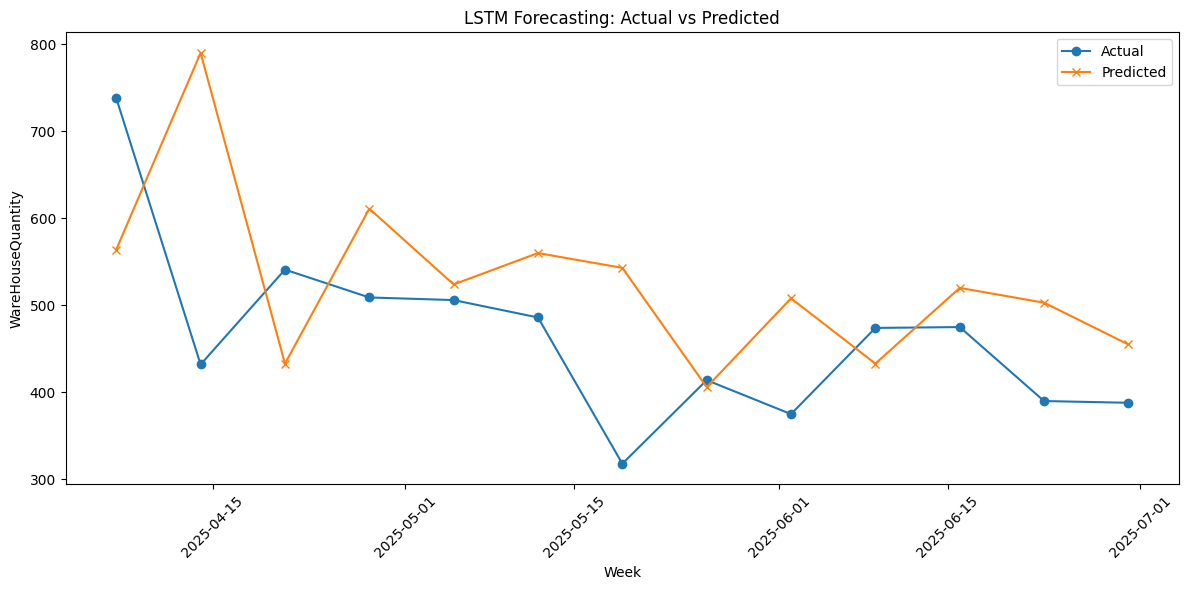

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(result_df['Start_Week'], result_df['Actual_WareHouseQuantity'], label='Actual', marker='o')
plt.plot(result_df['Start_Week'], result_df['Predicted_WareHouseQuantity'], label='Predicted', marker='x')
plt.xticks(rotation=45)
plt.title('LSTM Forecasting: Actual vs Predicted')
plt.xlabel('Week')
plt.ylabel('WareHouseQuantity')
plt.legend()
plt.tight_layout()
plt.show()


### Using `activation='mish', batch_size=64, sequence_length=18`

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 18
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------
model = Sequential()
model.add(LSTM(192, input_shape=(sequence_length, 1)))
model.add(Dense(64, activation='mish'))
model.add(Dense(32, activation='mish'))
model.add(Dense(1))  # Linear activation for regression

# ----------------------- STEP 4: Compile -----------------------
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# ----------------------- STEP 5: Callbacks -----------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6, verbose=1)

# ----------------------- STEP 6: Train Model -----------------------
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ----------------------- STEP 7: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 8: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 9: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save model and results
# model.save("best_lstm_model.h5")
# result_df.to_csv("best_model_results.csv", index=False)

# Return result
result_df


Epoch 1/200


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - loss: 0.1285 - mae: 0.3023 - val_loss: 0.0832 - val_mae: 0.2412 - learning_rate: 0.0100
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0558 - mae: 0.1840 - val_loss: 0.0633 - val_mae: 0.1961 - learning_rate: 0.0100
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0431 - mae: 0.1337 - val_loss: 0.0298 - val_mae: 0.1116 - learning_rate: 0.0100
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0289 - mae: 0.1224 - val_loss: 0.0347 - val_mae: 0.1094 - learning_rate: 0.0100
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0346 - mae: 0.1317 - val_loss: 0.0323 - val_mae: 0.1178 - learning_rate: 0.0100
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0241 - mae: 0.0940 - val_loss: 0.0344 - val_mae: 0.1105 - learning_rate: 0.0100
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0257 - mae: 0.0957 - val_loss: 0.0277 - val_mae: 0.0991 - learning_rate: 0.0100
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,573,-165.0,-22.36,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,633,201.0,46.53,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,449,-92.0,-17.01,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,490,-19.0,-3.73,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,502,-4.0,-0.79,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,520,34.0,7.00,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,523,205.0,64.47,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,425,11.0,2.66,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,466,91.0,24.27,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,457,-17.0,-3.59,426.6,521.4,Acceptable


In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 100
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------
model = Sequential()
model.add(LSTM(192, input_shape=(sequence_length, 1)))
model.add(Dense(64, activation='mish'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Linear activation for regression

# ----------------------- STEP 4: Compile -----------------------
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# ----------------------- STEP 5: Callbacks -----------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6, verbose=1)

# ----------------------- STEP 6: Train Model -----------------------
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ----------------------- STEP 7: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 8: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 9: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save model and results
# model.save("best_lstm_model.h5")
# result_df.to_csv("best_model_results.csv", index=False)

# Return result
result_df


Epoch 1/200


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1011 - mae: 0.2699 - val_loss: 0.0314 - val_mae: 0.1744 - learning_rate: 1.0000e-04
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0963 - mae: 0.2609 - val_loss: 0.0284 - val_mae: 0.1653 - learning_rate: 1.0000e-04
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0917 - mae: 0.2519 - val_loss: 0.0255 - val_mae: 0.1565 - learning_rate: 1.0000e-04
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.0873 - mae: 0.2432 - val_loss: 0.0229 - val_mae: 0.1479 - learning_rate: 1.0000e-04
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.0831 - mae: 0.2347 - val_loss: 0.0206 - val_mae: 0.1398 - learning_rate: 1.0000e-04
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.0794 - mae: 0.2267 - val_loss: 0.0184 - val_mae: 0.1316 - learning_rate: 1.0000e-04
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.0759 - mae: 0.2190 - val_loss: 0.0163 - val_mae: 0.1233 - learning_rate: 1.0000e-04


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,540,-198.0,-26.83,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,537,105.0,24.31,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,518,-23.0,-4.25,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509.0,506,-3.0,-0.59,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,495,-11.0,-2.17,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,484,-2.0,-0.41,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,474,156.0,49.06,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,455,41.0,9.90,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,443,68.0,18.13,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,430,-44.0,-9.28,426.6,521.4,Acceptable


In [21]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 100
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------
model = Sequential()
model.add(LSTM(192, input_shape=(sequence_length, 1)))
model.add(Dense(512, activation='mish'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # Linear activation for regression

# ----------------------- STEP 4: Compile -----------------------
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# ----------------------- STEP 5: Callbacks -----------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6, verbose=1)

# ----------------------- STEP 6: Train Model -----------------------
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ----------------------- STEP 7: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 8: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 9: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save model and results
# model.save("best_lstm_model.h5")
# result_df.to_csv("best_model_results.csv", index=False)

# Return result
result_df


Epoch 1/100


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1098 - mae: 0.2847 - val_loss: 0.0384 - val_mae: 0.1934 - learning_rate: 1.0000e-04
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.1079 - mae: 0.2815 - val_loss: 0.0372 - val_mae: 0.1904 - learning_rate: 1.0000e-04
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.1063 - mae: 0.2786 - val_loss: 0.0364 - val_mae: 0.1883 - learning_rate: 1.0000e-04
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.1051 - mae: 0.2766 - val_loss: 0.0353 - val_mae: 0.1853 - learning_rate: 1.0000e-04
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 0.1033 - mae: 0.2734 - val_loss: 0.0339 - val_mae: 0.1815 - learning_rate: 1.0000e-04
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.1012 - mae: 0.2695 - val_loss: 0.0323 - val_mae: 0.1768 - learning_rate: 1.0000e-04
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.0986 - mae: 0.2648 - val_loss: 0.0306 - val_mae: 0.1722 - learning_rate: 1.0000e-04


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,552,-186.0,-25.20,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,552,120.0,27.78,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,535,-6.0,-1.11,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509.0,526,17.0,3.34,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,517,11.0,2.17,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,508,22.0,4.53,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,499,181.0,56.92,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,481,67.0,16.18,372.6,455.4,Out of Range
8,2025-06-02,2025-06-08,375.0,471,96.0,25.60,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,460,-14.0,-2.95,426.6,521.4,Acceptable


### Bidirectional LSTM

In [22]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Bidirectional


# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 100
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------

model = Sequential()

# First Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(256, activation="mish", return_sequences=True), input_shape=(sequence_length, 1)))

# Second Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(64, activation="mish", return_sequences=False)))

# Dense Layers
model.add(Dense(512, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(128, activation="relu"))


# Dropout
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(Dense(1))

model.summary()

# model = keras.models.Sequential()
# # First Layer
# model.add(keras.layers.LSTM(512, return_sequences=True, input_shape=(sequence_length, 1)))
# # Second Layer
# model.add(keras.layers.LSTM(64, return_sequences=False))
# # Third Layer
# model.add(keras.layers.Dense(128, activation="mish"))
# model.add(keras.layers.Dense(64, activation="mish"))
# model.add(keras.layers.Dense(32, activation="mish"))
# model.add(keras.layers.Dense(16, activation="mish"))
# # Fourth Layer
# model.add(keras.layers.Dropout(0.2))
# # Final Layer
# model.add(keras.layers.Dense(1))

# model.summary()

# model.add(LSTM(192, input_shape=(sequence_length, 1)))
# model.add(Dense(64, activation='mish'))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(1))  # Linear activation for regression

# ----------------------- STEP 4: Compile -----------------------
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mae', metrics=[keras.metrics.RootMeanSquaredError()])

# ----------------------- STEP 5: Callbacks -----------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6, verbose=1)

# ----------------------- STEP 6: Train Model -----------------------
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ----------------------- STEP 7: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 8: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 9: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save model and results
# model.save("best_lstm_model.h5")
# result_df.to_csv("best_model_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100, 512)       │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,673 (3.77 MB)

 Trainable params: 988,673 (3.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2847 - root_mean_squared_error: 0.3314 - val_loss: 0.1945 - val_root_mean_squared_error: 0.1970 - learning_rate: 1.0000e-04
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - loss: 0.2832 - root_mean_squared_error: 0.3301 - val_loss: 0.1934 - val_root_mean_squared_error: 0.1959 - learning_rate: 1.0000e-04
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 0.2820 - root_mean_squared_error: 0.3291 - val_loss: 0.1921 - val_root_mean_squared_error: 0.1946 - learning_rate: 1.0000e-04
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - loss: 0.2807 - root_mean_squared_error: 0.3279 - val_loss: 0.1908 - val_root_mean_squared_error: 0.1933 - learning_rate: 1.0000e-04
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - loss: 0.2791 - root_mean_squared_error: 0.3265 - val_loss: 0.1894 - val_root_mean_squared_error: 0.1920 - learning_rate: 1.0000e-04
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 0.2780 - root_mean_

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,521,-217.0,-29.40,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,522,90.0,20.83,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,521,-20.0,-3.70,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509.0,520,11.0,2.16,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,519,13.0,2.57,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,517,31.0,6.38,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,517,199.0,62.58,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,516,102.0,24.64,372.6,455.4,Out of Range
8,2025-06-02,2025-06-08,375.0,514,139.0,37.07,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,514,40.0,8.44,426.6,521.4,Acceptable


### CNN LSTM

In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 20
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Split back to train/test using original train_data length
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# Reshape for Conv1D/LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# ======================= STEP 3: Build CNN-LSTM ========================
model = Sequential([
    # CNN feature extractor
    Conv1D(filters=64, kernel_size=3, padding="same", activation="relu",
           input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2),

    # LSTM to model temporal dependencies of extracted features
    LSTM(128, return_sequences=False),

    # Dense regression head
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)   # linear output for regression
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= (Optional) Save ===============================
# model.save("cnn_lstm_model.h5")
# result_df.to_csv("cnn_lstm_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,745 (467.75 KB)

 Trainable params: 119,745 (467.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - loss: 0.2094 - root_mean_squared_error: 0.2624 - val_loss: 0.2546 - val_root_mean_squared_error: 0.3046 - learning_rate: 1.0000e-04
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.2038 - root_mean_squared_error: 0.2584 - val_loss: 0.2464 - val_root_mean_squared_error: 0.2979 - learning_rate: 1.0000e-04
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1969 - root_mean_squared_error: 0.2521 - val_loss: 0.2380 - val_root_mean_squared_error: 0.2911 - learning_rate: 1.0000e-04
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1902 - root_mean_squared_error: 0.2469 - val_loss: 0.2295 - val_root_mean_squared_error: 0.2843 - learning_rate: 1.0000e-04
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1860 - root_mean_squared_error: 0.2432 - val_loss: 0.2210 - val_root_mean_squared_error: 0.2775 - learning_rate: 1.0000e-04
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1787 - root_mean_sq

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,536,-202.0,-27.37,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,526,94.0,21.76,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,502,-39.0,-7.21,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509.0,475,-34.0,-6.68,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,471,-35.0,-6.92,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,465,-21.0,-4.32,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,451,133.0,41.82,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,436,22.0,5.31,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,414,39.0,10.40,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,393,-81.0,-17.09,426.6,521.4,Out of Range


In [24]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 20
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Split back to train/test using original train_data length
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# Reshape for Conv1D/LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# ======================= STEP 3: Build CNN-LSTM ========================
model = Sequential([
    # CNN feature extractor
    Conv1D(filters=64, kernel_size=3, padding="same", activation="mish",
           input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, padding="same", activation="mish"),
    MaxPooling1D(pool_size=2),

    # LSTM to model temporal dependencies of extracted features
    LSTM(64, return_sequences=False),

    # Dense regression head
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1)   # linear output for regression
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.6,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= (Optional) Save ===============================
# model.save("cnn_lstm_model.h5")
# result_df.to_csv("cnn_lstm_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 20, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,857 (194.75 KB)

 Trainable params: 49,857 (194.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2157 - root_mean_squared_error: 0.2942 - val_loss: 0.2034 - val_root_mean_squared_error: 0.2406 - learning_rate: 5.0000e-04
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.2048 - root_mean_squared_error: 0.2864 - val_loss: 0.1897 - val_root_mean_squared_error: 0.2291 - learning_rate: 5.0000e-04
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.1944 - root_mean_squared_error: 0.2764 - val_loss: 0.1758 - val_root_mean_squared_error: 0.2178 - learning_rate: 5.0000e-04
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.1811 - root_mean_squared_error: 0.2680 - val_loss: 0.1610 - val_root_mean_squared_error: 0.2061 - learning_rate: 5.0000e-04
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.1711 - root_mean_squared_error: 0.2601 - val_loss: 0.1451 - val_root_mean_squared_error: 0.1942 - learning_rate: 5.0000e-04
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 0.1581 - root_mean_

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,574,-164.0,-22.22,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,558,126.0,29.17,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,532,-9.0,-1.66,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509.0,521,12.0,2.36,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,519,13.0,2.57,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,508,22.0,4.53,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,497,179.0,56.29,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,484,70.0,16.91,372.6,455.4,Out of Range
8,2025-06-02,2025-06-08,375.0,465,90.0,24.00,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,446,-28.0,-5.91,426.6,521.4,Acceptable


### Results

In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 8
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Split back to train/test using original train_data length
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# Reshape for Conv1D/LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# ======================= STEP 3: Build CNN-LSTM ========================
model = Sequential([
    # CNN feature extractor
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish",
           input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish"),
    MaxPooling1D(pool_size=2),

    # LSTM to model temporal dependencies of extracted features
    LSTM(64, return_sequences=False),

    # Dense regression head
    Dense(64, activation="mish"),
    Dense(64, activation="mish"),
    Dropout(0.2),
    Dense(1)   # linear output for regression
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.6,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= (Optional) Save ===============================
# model.save("cnn_lstm_model.h5")
# result_df.to_csv("cnn_lstm_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 8, 128)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 4, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,609 (549.25 KB)

 Trainable params: 140,609 (549.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.1448 - root_mean_squared_error: 0.1751 - val_loss: 0.2432 - val_root_mean_squared_error: 0.3003 - learning_rate: 5.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.1368 - root_mean_squared_error: 0.1683 - val_loss: 0.2333 - val_root_mean_squared_error: 0.2923 - learning_rate: 5.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.1283 - root_mean_squared_error: 0.1615 - val_loss: 0.2228 - val_root_mean_squared_error: 0.2838 - learning_rate: 5.0000e-04
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - loss: 0.1194 - root_mean_squared_error: 0.1549 - val_loss: 0.2113 - val_root_mean_squared_error: 0.2747 - learning_rate: 5.0000e-04
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.1107 - root_mean_squared_error: 0.1474 - val_loss: 0.1987 - val_root_mean_squared_error: 0.2650 - learning_rate: 5.0000e-04
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.1014 - root_mean_square

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,457,-281.0,-38.08,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,465,33.0,7.64,388.8,475.2,Acceptable
2,2025-04-21,2025-04-27,541.0,462,-79.0,-14.60,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,464,-45.0,-8.84,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,467,-39.0,-7.71,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,462,-24.0,-4.94,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,458,140.0,44.03,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,445,31.0,7.49,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,441,66.0,17.60,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,429,-45.0,-9.49,426.6,521.4,Acceptable


In [26]:
### Change the optimizer

In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD

import matplotlib.pyplot as plt

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 8
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Split back to train/test using original train_data length
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# Reshape for Conv1D/LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# ======================= STEP 3: Build CNN-LSTM ========================
model = Sequential([
    # CNN feature extractor
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish",
           input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish"),
    MaxPooling1D(pool_size=2),

    # LSTM to model temporal dependencies of extracted features
    LSTM(64, return_sequences=False),

    # Dense regression head
    Dense(64, activation="mish"),
    Dense(64, activation="mish"),
    Dropout(0.2),
    Dense(1)   # linear output for regression
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = Adam(learning_rate=0.0005)

# optimizer = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.5,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= (Optional) Save ===============================
# model.save("cnn_lstm_model.h5")
# result_df.to_csv("cnn_lstm_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 8, 128)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 4, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,609 (549.25 KB)

 Trainable params: 140,609 (549.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.1888 - root_mean_squared_error: 0.2617 - val_loss: 0.2211 - val_root_mean_squared_error: 0.2570 - learning_rate: 5.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.1802 - root_mean_squared_error: 0.2552 - val_loss: 0.2116 - val_root_mean_squared_error: 0.2487 - learning_rate: 5.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - loss: 0.1708 - root_mean_squared_error: 0.2486 - val_loss: 0.2015 - val_root_mean_squared_error: 0.2400 - learning_rate: 5.0000e-04
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.1612 - root_mean_squared_error: 0.2408 - val_loss: 0.1905 - val_root_mean_squared_error: 0.2307 - learning_rate: 5.0000e-04
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.1513 - root_mean_squared_error: 0.2334 - val_loss: 0.1785 - val_root_mean_squared_error: 0.2206 - learning_rate: 5.0000e-04
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.1408 - root_mean_square

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,471,-267.0,-36.18,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,478,46.0,10.65,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,474,-67.0,-12.38,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,475,-34.0,-6.68,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,479,-27.0,-5.34,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,474,-12.0,-2.47,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,471,153.0,48.11,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,456,42.0,10.14,372.6,455.4,Out of Range
8,2025-06-02,2025-06-08,375.0,452,77.0,20.53,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,440,-34.0,-7.17,426.6,521.4,Acceptable


In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 12
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Split back to train/test using original train_data length
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# Reshape for Conv1D/LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# ======================= STEP 3: Build CNN-LSTM ========================
model = Sequential([
    # CNN feature extractor
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish",
           input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish"),
    MaxPooling1D(pool_size=2),

    # LSTM to model temporal dependencies of extracted features
    LSTM(64, return_sequences=False),

    # Dense regression head
    Dense(64, activation="mish"),
    Dense(64, activation="mish"),
    Dropout(0.2),
    Dense(1)   # linear output for regression
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.6,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= (Optional) Save ===============================
# model.save("cnn_lstm_model.h5")
# result_df.to_csv("cnn_lstm_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 12, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 6, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,609 (549.25 KB)

 Trainable params: 140,609 (549.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.1639 - root_mean_squared_error: 0.2072 - val_loss: 0.2328 - val_root_mean_squared_error: 0.2890 - learning_rate: 5.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step - loss: 0.1545 - root_mean_squared_error: 0.1995 - val_loss: 0.2206 - val_root_mean_squared_error: 0.2792 - learning_rate: 5.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.1446 - root_mean_squared_error: 0.1915 - val_loss: 0.2074 - val_root_mean_squared_error: 0.2688 - learning_rate: 5.0000e-04
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.1339 - root_mean_squared_error: 0.1830 - val_loss: 0.1927 - val_root_mean_squared_error: 0.2575 - learning_rate: 5.0000e-04
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - loss: 0.1231 - root_mean_squared_error: 0.1743 - val_loss: 0.1762 - val_root_mean_squared_error: 0.2453 - learning_rate: 5.0000e-04
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 0.1132 - root_mean_square

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,507,-231.0,-31.30,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,486,54.0,12.50,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,459,-82.0,-15.16,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,450,-59.0,-11.59,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506.0,451,-55.0,-10.87,455.4,556.6,Out of Range
5,2025-05-12,2025-05-18,486.0,449,-37.0,-7.61,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,447,129.0,40.57,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,442,28.0,6.76,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,440,65.0,17.33,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,432,-42.0,-8.86,426.6,521.4,Acceptable


### Stacked LSTM

In [29]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 12
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Split back to train/test using original train_data length
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# ======================= STEP 3: Build STACKED LSTM ====================
model = Sequential([
    # Stacked LSTMs: all but last set return_sequences=True
    LSTM(128, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.1),
    LSTM(32, return_sequences=False),
    Dropout(0.1),

    # Dense regression head
    Dense(64, activation="mish"),
    Dense(32, activation="mish"),
    Dense(1)  # linear output for regression
])

model.summary()

# ======================= STEP 4: Compile ===============================
# optimizer = AdamW(learning_rate=0.0001)
optimizer = AdamW(learning_rate=0.0001, weight_decay=1e-5)

model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=200,                # ↑ more epochs since LSTMs may need longer
    batch_size=256,
    validation_split=0.1,      # keep as in your script
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= (Optional) Save ===============================
# model.save("stacked_lstm_model.h5")
# result_df.to_csv("stacked_lstm_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 12, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 12, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,609 (518.00 KB)

 Trainable params: 132,609 (518.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.2070 - root_mean_squared_error: 0.2606 - val_loss: 0.2711 - val_root_mean_squared_error: 0.3183 - learning_rate: 1.0000e-04
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.2048 - root_mean_squared_error: 0.2587 - val_loss: 0.2685 - val_root_mean_squared_error: 0.3161 - learning_rate: 1.0000e-04
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.2026 - root_mean_squared_error: 0.2570 - val_loss: 0.2658 - val_root_mean_squared_error: 0.3138 - learning_rate: 1.0000e-04
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.2006 - root_mean_squared_error: 0.2554 - val_loss: 0.2631 - val_root_mean_squared_error: 0.3115 - learning_rate: 1.0000e-04
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.1986 - root_mean_squared_error: 0.2538 - val_loss: 0.2604 - val_root_mean_squared_error: 0.3093 - learning_rate: 1.0000e-04
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1963 - root_mean_squar

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,535,-203.0,-27.51,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,497,65.0,15.05,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,448,-93.0,-17.19,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,432,-77.0,-15.13,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506.0,431,-75.0,-14.82,455.4,556.6,Out of Range
5,2025-05-12,2025-05-18,486.0,431,-55.0,-11.32,437.4,534.6,Out of Range
6,2025-05-19,2025-05-25,318.0,428,110.0,34.59,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,432,18.0,4.35,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,434,59.0,15.73,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,433,-41.0,-8.65,426.6,521.4,Acceptable


### With lags

In [35]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# ---------- Create Lag & Rolling Features ----------
df['lag_1']  = df['WareHouseQuantity'].shift(1)
df['lag_2']  = df['WareHouseQuantity'].shift(2)
df['lag_7']  = df['WareHouseQuantity'].shift(7)
df['rolling_mean_3'] = df['WareHouseQuantity'].shift(1).rolling(3).mean()
df['rolling_mean_7'] = df['WareHouseQuantity'].shift(1).rolling(7).mean()

# Drop rows with NaN (due to shifting)
df = df.dropna().reset_index(drop=True)

# Features for LSTM (multi-feature input)
features = ['WareHouseQuantity','lag_1','lag_2','lag_7','rolling_mean_3','rolling_mean_7']

# Normalize
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length, 0])  # predict original quantity
    return np.array(X), np.array(y)

sequence_length = 12
X_all, y_all = create_sequences(scaled, sequence_length)

# Split back to train/test using original train_data length
train_len = len(train_data) - df.index.min()  # adjust for dropped NaN
X_train = X_all[:train_len - sequence_length]
y_train = y_all[:train_len - sequence_length]
X_test  = X_all[train_len - sequence_length:]
y_test  = y_all[train_len - sequence_length:]

print("X_train shape:", X_train.shape)  # (samples, timesteps, features)
print("X_test shape :", X_test.shape)

# ======================= STEP 3: Build STACKED LSTM ====================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(sequence_length, X_train.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.1),
    LSTM(32, return_sequences=False),
    Dropout(0.1),

    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)  # linear output
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = AdamW(learning_rate=0.0001, weight_decay=1e-5)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
# Only inverse-transform "WareHouseQuantity" column
dummy = np.zeros((len(y_pred_scaled), scaled.shape[1]))
dummy[:,0] = y_pred_scaled.flatten()
y_pred = scaler.inverse_transform(dummy)[:,0]

dummy_true = np.zeros((len(y_test), scaled.shape[1]))
dummy_true[:,0] = y_test.flatten()
y_true = scaler.inverse_transform(dummy_true)[:,0]

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# result_df.to_csv("stacked_lstm_with_lags.csv", index=False)
result_df


X_train shape: (119, 12, 6)
X_test shape : (6, 12, 6)


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 12, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 12, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,169 (528.00 KB)

 Trainable params: 135,169 (528.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.2000 - root_mean_squared_error: 0.2625 - val_loss: 0.1461 - val_root_mean_squared_error: 0.1515 - learning_rate: 1.0000e-04
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.1974 - root_mean_squared_error: 0.2598 - val_loss: 0.1412 - val_root_mean_squared_error: 0.1467 - learning_rate: 1.0000e-04
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.1939 - root_mean_squared_error: 0.2578 - val_loss: 0.1365 - val_root_mean_squared_error: 0.1421 - learning_rate: 1.0000e-04
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.1907 - root_mean_squared_error: 0.2548 - val_loss: 0.1316 - val_root_mean_squared_error: 0.1373 - learning_rate: 1.0000e-04
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.1881 - root_mean_squared_error: 0.2529 - val_loss: 0.1252 - val_root_mean_squared_error: 0.1310 - learning_rate: 1.0000e-04
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - loss: 0.1840 - root_mean_

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,414.0,426,12.0,2.90,372.6,455.4,Acceptable
1,2025-04-14,2025-04-20,375.0,407,32.0,8.53,337.5,412.5,Acceptable
2,2025-04-21,2025-04-27,474.0,391,-83.0,-17.51,426.6,521.4,Out of Range
3,2025-04-28,2025-05-04,475.0,386,-89.0,-18.74,427.5,522.5,Out of Range
4,2025-05-05,2025-05-11,390.0,383,-7.0,-1.79,351.0,429.0,Acceptable
5,2025-05-12,2025-05-18,388.0,379,-9.0,-2.32,349.2,426.8,Acceptable


In [87]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week', 'WareHouseQuantity', 'Week_Start', 'Week_End']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# ---------- Create Lag & Rolling Features ----------
df['lag_1']  = df['WareHouseQuantity'].shift(1)
df['lag_2']  = df['WareHouseQuantity'].shift(2)
df['lag_7']  = df['WareHouseQuantity'].shift(7)
df['rolling_mean_3'] = df['WareHouseQuantity'].shift(1).rolling(3).mean()
df['rolling_mean_7'] = df['WareHouseQuantity'].shift(1).rolling(7).mean()

# Drop rows with NaN (due to shifting)
df = df.dropna().reset_index(drop=True)

# Features for LSTM (multi-feature input)
features = ['WareHouseQuantity','lag_1','lag_2','lag_7','rolling_mean_3','rolling_mean_7']

# Normalize
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length, 0])  # predict original quantity
    return np.array(X), np.array(y)

sequence_length = 15
X_all, y_all = create_sequences(scaled, sequence_length)

# Train/test split based on train_data length
train_len = len(train_data) - (len(train_data) + len(test_data) - len(df))  # adjust for dropped NaN
X_train = X_all[:train_len - sequence_length]
y_train = y_all[:train_len - sequence_length]
X_test  = X_all[train_len - sequence_length:]
y_test  = y_all[train_len - sequence_length:]

print("X_train shape:", X_train.shape)  # (samples, timesteps, features)
print("X_test shape :", X_test.shape)

# ======================= STEP 3: Build STACKED LSTM ====================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(sequence_length, X_train.shape[2])),
    Dropout(0.4),
    LSTM(128, return_sequences=True, activation='tanh'),
    Dropout(0.1),
    LSTM(64, return_sequences=False, activation='tanh'),
    Dropout(0.1),

    Dense(64, activation="mish"),
    Dense(64, activation="relu"),
    Dense(1)  # linear output
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = Nadam(learning_rate=0.0001, weight_decay=1e-5)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=20, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)

# Only inverse-transform "WareHouseQuantity" column
dummy = np.zeros((len(y_pred_scaled), scaled.shape[1]))
dummy[:,0] = y_pred_scaled.flatten()
y_pred = scaler.inverse_transform(dummy)[:,0]

dummy_true = np.zeros((len(y_test), scaled.shape[1]))
dummy_true[:,0] = y_test.flatten()
y_true = scaler.inverse_transform(dummy_true)[:,0]

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame (FIXED ALIGNMENT) ===
# Align test weeks exactly with predicted length
test_weeks_aligned = df.iloc[train_len:].reset_index(drop=True)
# Pick exactly len(y_pred) rows
test_weeks_aligned = test_weeks_aligned.iloc[:len(y_pred)]

start_weeks = test_weeks_aligned['Week_Start'].to_numpy()
end_weeks   = test_weeks_aligned['Week_End'].to_numpy()
actuals_np  = test_weeks_aligned['WareHouseQuantity'].to_numpy()

predicted_np = np.round(y_pred.flatten()).astype(int)
minus_10 = (actuals_np * 0.9).round(2)
plus_10  = (actuals_np * 1.1).round(2)

within_10 = (predicted_np >= minus_10) & (predicted_np <= plus_10)
status = np.where(within_10, "Acceptable", "Out of Range")

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals_np,
    'Predicted_WareHouseQuantity': predicted_np,
    'Difference_Between_Predicted_And_Actual': predicted_np - actuals_np,
    'Percent_Difference': (((predicted_np - actuals_np) / actuals_np) * 100).round(2),
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= Save (Optional) ===============================
# model.save("stacked_lstm_with_lags.h5")
# result_df.to_csv("stacked_lstm_with_lags_results.csv", index=False)

# Return result
result_df


X_train shape: (109, 15, 6)
X_test shape : (13, 15, 6)


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_150 (LSTM)                 │ (None, 15, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_144 (Dropout)           │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_151 (LSTM)                 │ (None, 15, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_145 (Dropout)           │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_152 (LSTM)                 │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_146 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,497 (1009.75 KB)

 Trainable params: 258,497 (1009.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 402ms/step - loss: 0.1969 - root_mean_squared_error: 0.2584 - val_loss: 0.2118 - val_root_mean_squared_error: 0.2617 - learning_rate: 1.0000e-04
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1888 - root_mean_squared_error: 0.2525 - val_loss: 0.2008 - val_root_mean_squared_error: 0.2534 - learning_rate: 1.0000e-04
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1821 - root_mean_squared_error: 0.2472 - val_loss: 0.1881 - val_root_mean_squared_error: 0.2440 - learning_rate: 1.0000e-04
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1737 - root_mean_squared_error: 0.2409 - val_loss: 0.1736 - val_root_mean_squared_error: 0.2337 - learning_rate: 1.0000e-04
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1657 - root_mean_squared_error: 0.2344 - val_loss: 0.1572 - val_root_mean_squared_error: 0.2226 - learning_rate: 1.0000e-04
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1554 - root_mean_sq

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738,590,-148,-20.05,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432,582,150,34.72,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541,573,32,5.91,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509,560,51,10.02,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506,535,29,5.73,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486,508,22,4.53,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318,484,166,52.20,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414,463,49,11.84,372.6,455.4,Out of Range
8,2025-06-02,2025-06-08,375,448,73,19.47,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474,434,-40,-8.44,426.6,521.4,Acceptable


In [41]:
test_data.head()

,Week,WareHouseQuantity,Week_Start,Week_End
1950,2025-04-07,738,2025-04-07,2025-04-13
1959,2025-04-14,432,2025-04-14,2025-04-20
1968,2025-04-21,541,2025-04-21,2025-04-27
1978,2025-04-28,509,2025-04-28,2025-05-04
1987,2025-05-05,506,2025-05-05,2025-05-11


In [258]:
# !pip install xgboost


In [33]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ================= STEP 1: Prepare Data =================
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Create lag features
def create_lag_features(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])  # past sequence_length values
        y.append(data[i])  # current value
    return np.array(X), np.array(y)

sequence_length = 9
X_all, y_all = create_lag_features(df['WareHouseQuantity'].values, sequence_length)

# Train/Test split (use same split as before)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# ================= STEP 2: Train XGBoost =================
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=9,
    subsample=0.8,
    colsample_bytree=0.6,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

# ================= STEP 3: Predictions ==================
y_pred = model.predict(X_test)

# ================= STEP 4: Evaluation ===================
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ================= STEP 5: Result DataFrame ==============
start_weeks = test_data['Week_Start'].iloc[:len(y_test)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_test)].reset_index(drop=True)

actuals    = pd.Series(y_test).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# (Optional) Save
# model.save_model("xgb_model.json")
# result_df.to_csv("xgb_results.csv", index=False)

result_df


MAE: 81.28417205810547
RMSE: 104.55752659272072
R2 Score: -0.09747457504272461

Accuracy within ±10% of predicted values: 46.15%


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738,567,-171,-23.17,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432,593,161,37.27,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541,514,-27,-4.99,486.9,595.1,Acceptable
3,2025-04-28,2025-05-04,509,541,32,6.29,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506,505,-1,-0.20,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486,492,6,1.23,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318,506,188,59.12,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414,428,14,3.38,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375,468,93,24.80,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474,558,84,17.72,426.6,521.4,Out of Range


In [93]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# ======================= STEP 0: Set Random Seed =======================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# ======================= STEP 1: Prepare Data ==========================
# Assumes you already have train_data, test_data with columns:
# ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ======================= STEP 2: Create Sequences ======================
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 8
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Split back to train/test using original train_data length
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test  = X_all[len(train_data) - sequence_length:]
y_test  = y_all[len(train_data) - sequence_length:]

# Reshape for Conv1D/LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# ======================= STEP 3: Build CNN-LSTM ========================
model = Sequential([
    # CNN feature extractor
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish",
           input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, padding="same", activation="mish"),
    MaxPooling1D(pool_size=2),

    # LSTM to model temporal dependencies of extracted features
    LSTM(64, return_sequences=False),

    # Dense regression head
    Dense(64, activation="mish"),
    Dense(64, activation="mish"),
    Dropout(0.2),
    Dense(1)   # linear output for regression
])

model.summary()

# ======================= STEP 4: Compile ===============================
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

# ======================= STEP 5: Callbacks =============================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5,
                              min_lr=1e-6, verbose=1)

# ======================= STEP 6: Train Model ===========================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.6,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ======================= STEP 7: Predict ===============================
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================= STEP 8: Evaluation ============================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ======================= STEP 9: Result DataFrame ======================
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks   = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals    = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted  = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10  = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# ======================= (Optional) Save ===============================
# model.save("cnn_lstm_model.h5")
# result_df.to_csv("cnn_lstm_results.csv", index=False)

# Return result
result_df


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 8, 128)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 4, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_153 (LSTM)                 │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_147 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_177 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,609 (549.25 KB)

 Trainable params: 140,609 (549.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1448 - root_mean_squared_error: 0.1751 - val_loss: 0.2432 - val_root_mean_squared_error: 0.3003 - learning_rate: 5.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.1368 - root_mean_squared_error: 0.1683 - val_loss: 0.2333 - val_root_mean_squared_error: 0.2923 - learning_rate: 5.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.1283 - root_mean_squared_error: 0.1615 - val_loss: 0.2228 - val_root_mean_squared_error: 0.2838 - learning_rate: 5.0000e-04
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.1194 - root_mean_squared_error: 0.1549 - val_loss: 0.2113 - val_root_mean_squared_error: 0.2747 - learning_rate: 5.0000e-04
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.1107 - root_mean_squared_error: 0.1474 - val_loss: 0.1987 - val_root_mean_squared_error: 0.2650 - learning_rate: 5.0000e-04
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1014 - root_mean_squared_er

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,457,-281.0,-38.08,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,465,33.0,7.64,388.8,475.2,Acceptable
2,2025-04-21,2025-04-27,541.0,462,-79.0,-14.60,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,464,-45.0,-8.84,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,467,-39.0,-7.71,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,462,-24.0,-4.94,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,458,140.0,44.03,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,445,31.0,7.49,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,441,66.0,17.60,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,429,-45.0,-9.49,426.6,521.4,Acceptable
